# Nonparametric Regressions

This notebook uses non-parametric methods for regression estimates.

# Load Packages and Extra Functions

The key functions used in this notebook are in the (local) `FinEcmt_KernelRegression` module. 

In [1]:
MyModulePath = joinpath(pwd(),"src")
!in(MyModulePath,LOAD_PATH) && push!(LOAD_PATH,MyModulePath)
using FinEcmt_OLS, FinEcmt_KernelRegression

In [2]:
#=
include(joinpath(pwd(),"src","FinEcmt_OLS.jl"))
include(joinpath(pwd(),"src","FinEcmt_KernelRegression.jl"))
using .FinEcmt_OLS, .FinEcmt_KernelRegression
=#

In [3]:
using DelimitedFiles, Statistics

In [4]:
using Plots
default(size = (480,320),fmt = :png)

## Loading Data

The data consists of daily returns on S&P 500.

In [5]:
xx = readdlm("Data/ReSP500Daily.csv",',',skipstart=1)
R  = excise(Float64.(xx[:,2]))       #delete NaNs
xx = nothing

# Kernel Regression

is a regression of the sort 
$y_t = b(x_{t}) + \epsilon_t$ where 
where regression function $b()$ is estimated by using data in the neighbourhood of a grid point $\tilde{x}$

$\hat{b}(\tilde{x})=\frac{\sum_{t=1}^{T}w(u_t)y_{t}}{\sum_{t=1}^{T}w(u_t)},$

where $u_t=(x_t-\tilde{x})/h$

where $w(u_t)$ is the weight of observation $t$, defined by a kernel function. This can be implemented as a regression 
of $\sqrt{w_t}y_t$ on $\sqrt{w_t}1$, which also gives a valid standard error of the estimates. (The function below uses White's method.)

The function `KernelRegression()` uses one of several available kernels, defaulting to the Gaussian kernel. The function requires the user to input a bandwidth parameter `h`, which controls how quick $w(u_t)$ tapers off as a $x_t$ deviates from $\tilde{x}$.

As an alternative to this code, consider the [NonparametricRegression.jl](https://github.com/tbeason/NonparametricRegression.jl) package.

In the application below, we are estimating a non-parametric AR(1) for returns.

In [6]:
@doc2 KernelRegression

```julia
KernelRegression(y,x,xGrid,h,vv = :all,DoCovb=true,KernelFun=GaussianKernel)
```

Do kernel regression `y[vv] = b(x[vv])`, evaluated at each point in the `xGrid` vector, using bandwidth `h`. Implemented as weighted least squares (WLS), which also provide heteroskedasticity robust standard errors.

### Input

  * `y::Vector`:      T-vector with data for the dependent variable
  * `x::Vector`:      T-vector with data for the regressor
  * `xGrid::Vector`:  Ngrid-vector with grid points where the estimates are done
  * `vv::Symbol or Vector`: If `vv = :all`, then all data points are used, otherwise supply indices.
  * `DoCovb::Bool`:    If true, the standard error of the estimate is also calculated
  * `KernelFun::Function`: Function used as kernel.

### Remark

  * The `vv` and `DoCovb=false` options are useful for speeding up the cross-validation below.


In [7]:
#println(@code_string KernelRegression([1],[1],[1],1))

In [8]:
(y,x) = (R[2:end],R[1:end-1])               #return, return[t-1]
T     = size(y,1)
println("Sample size: $T")

xGrid = range(-6.8,6.8,81)                 #x values to estimate b(x) at, as in LN
h     = 1.4

(bHat,StdbHat) = KernelRegression(y,x,xGrid,h)             #baseline choice of h
bHatHih,       = KernelRegression(y,x,xGrid,h*1.5)         #high h
bHatLoh,       = KernelRegression(y,x,xGrid,h/10);         #low h

Sample size: 11478


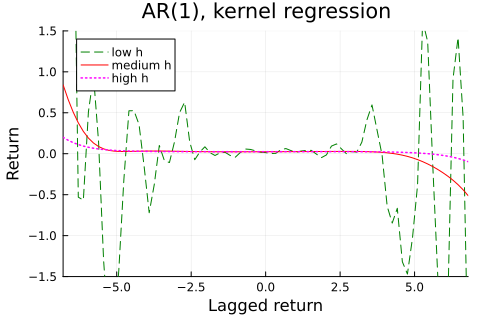

In [9]:
p1 = plot( xGrid,[bHatLoh bHat bHatHih],
           linestyle = [:dash :solid :dot],
           linewidth = [1 1 1.5],
           label = ["low h" "medium h" "high h"],
           color = [:green :red :magenta],
           xlim = extrema(xGrid),
           ylim = (-1.5,1.5),
           title = "AR(1), kernel regression",
           xlabel = "Lagged return",
           ylabel = "Return" )
display(p1)

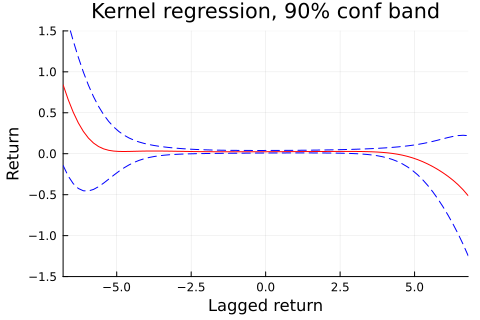

In [10]:
p1 = plot( xGrid,[bHat (bHat-1.645*StdbHat) bHat+1.645*StdbHat],
           linecolor = [:red :blue :blue],
           linestyle = [:solid :dash :dash],
           label = "",
           title = "Kernel regression, 90% conf band",
           xlabel = "Lagged return",
           ylabel = "Return",
           xlim = extrema(xGrid),
           ylim = (-1.5,1.5),
           annotation = (-5,-4,text("using medium h",8)))
display(p1)

## Rule of Thumb Choice of $h$

for the non-parametric regression.

Run the regression 

$y=\alpha+\beta x+\gamma x^{2}+\varepsilon$

and use the following rule-of-thumb choice

$h  =T^{-1/5}|\gamma|^{-2/5}\sigma_{\varepsilon}^{2/5}(x_{\max}-x_{\min})^{1/5}\times0.6.$

In practice, replace $x_{\max}-x_{\min}$ by the difference between the 90th
and 10th percentiles of $x$.

This is implemented in the `hRuleOfThumb()` function (included above).

In [11]:
h_crude = hRuleOfThumb(y,x)
printlnPs("\nRule-of-thumb value of h: ",h_crude)


Rule-of-thumb value of h:      0.724


## Cross-Validation (extra)

to choose the bandwidth $h$ for the kernel regression.

To do a cross-validation (leave-one-out)

(1) Pick a bandwidth $h$, do the kernel regression
but leave out observation $t$ and then record the out-of-sample prediction error $y_{t}-\hat{b}_{-t}
(x_{t},h)$. Notice that this is the error for observation $t$ only. 

(2) Repeat for all $t=1-T$ to calculate the CV

$\text{CV}(h)=\sum_{t=1}^{T}[  y_{t}-\hat{b}_{-t}(x_{t},h)]  ^{2}/T,$

(3) Finally, redo for several different values of $h$, and pick the $h$ value
that minimizes $\text{CV}(h)$. 

### A Remark on the Code

Notice: Cross-validation calculations *take some time*. The code below uses a slightly optimized version. The package also contains a slower brute-force version (`CrossValidateKernelR()`).

In [12]:
hM = range(0.25,3,length=15)   #candiate h values

CV = CrossValidateKernelR2(y,x,hM)
CV_rel = (CV/minimum(CV) .- 1)*100;     #% deviation from minimum

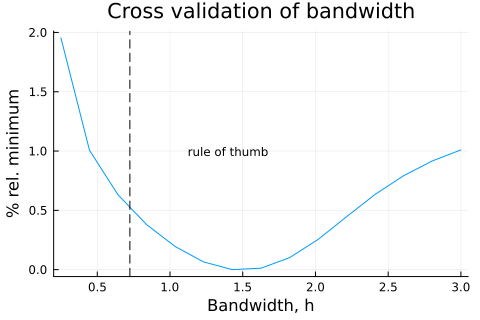

In [13]:
p1 = plot( hM,CV_rel,
           legend = false,
           xlim = (minimum(hM)-0.05,maximum(hM)+0.05),
           #ylim = (0.99,1.025),
           title = "Cross validation of bandwidth",
           xlabel = "Bandwidth, h",
           ylabel = "% rel. minimum",
           annotation = (1.4,0.995,text("rule of thumb",8)) )
vline!([h_crude],linecolor=:black,line=(:dash,1))
display(p1)

# Local Linear Regression

estimates 

$y_t = a + b (x_t-x) + \epsilon_t$

for a grid of $x$ values. This can also be implemented as weighted least squares (which gives both point estimates and valid standard errors). This is implemented in the `LocalLinearRegression()` function.

In [14]:
@doc2 LocalLinearRegression

```julia
LocalLinearRegression(y,x,xGrid,h,vv = :all,DoCovb=true,KernelFun=GaussianKernel)
```

Do local linear regression `y = a + b(x-xGrid[i])`, where both `a` and `b` will differ across `xGrid[i]` values. The estimates of `a` and their standard errors are exported.

See `KernRegrFn()` for further comments


In [15]:
#println(@code_string LocalLinearRegression([1],[1],[1],1))

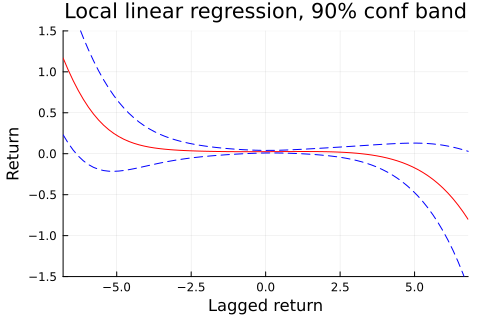

In [16]:
#xGrid = -10:0.25:10                          #x values to estimate b(x) at
h     = 2.25
(aHat,StdaHat) = LocalLinearRegression(y,x,xGrid,h);             #baseline choice of h

p1 = plot( xGrid,[aHat (aHat-1.645*StdaHat) aHat+1.645*StdaHat],
           linecolor = [:red :blue :blue],
           linestyle = [:solid :dash :dash],
           label = "",
           title = "Local linear regression, 90% conf band",
           xlabel = "Lagged return",
           ylabel = "Return",
           xlim = extrema(xGrid),
           ylim = (-1.5,1.5) )
display(p1)